In [162]:
import warnings
warnings.filterwarnings("ignore")

In [163]:
from tqdm import tqdm
import pandas as pd
from datetime import datetime, timedelta
import sqlite3
import mysql.connector
import pyarrow

import numpy as np

import matplotlib.pyplot as plt


In [164]:
connection = mysql.connector.connect(
    user = 'root',
    password = 'root',
    host = 'localhost',
    port = 3306,
    database = 'Historical_Data'
)
print("MySQL DB Connected")


MySQL DB Connected


In [165]:
cursor = connection.cursor()

cursor.execute("SELECT * FROM FT_HOUR_DATA")

results = cursor.fetchall()

columns = [column[0] for column in cursor.description]


df_original = pd.DataFrame(results, columns=columns)

In [166]:
df_original.sort_values(by = 'id_date', ascending = True)

,Open,High,Low,Close,adj_close,Volume,Hour,Exchange,id_exchange,id_date
0,29432,29473,29393,29460,29460,0,0,BTC-USD,1,20220522
69661,10,10,10,10,10,0,15,DOT-USD,8,20220522
69660,10,10,10,10,10,4360352,14,DOT-USD,8,20220522
69659,10,10,10,10,10,2552736,13,DOT-USD,8,20220522
69658,10,10,10,10,10,7405792,12,DOT-USD,8,20220522
...,...,...,...,...,...,...,...,...,...,...
34818,3065,3081,3065,3075,3075,97893376,20,ETH-USD,2,20240519
34817,3071,3081,3063,3065,3065,332815360,19,ETH-USD,2,20240519
34816,3073,3077,3070,3071,3071,20900864,18,ETH-USD,2,20240519
52213,1,1,1,1,1,1778784,3,XRP-USD,3,20240519


In [167]:
df = df_original[['id_date', 'Hour', 'Close','Exchange']]

df['id_date'] = pd.to_datetime(df['id_date'], format='%Y%m%d')
df['datetime'] = df['id_date'] + pd.to_timedelta(df['Hour'], unit='h')

df = df[['datetime', 'Close', 'Exchange']]

In [168]:
df = df[df['Exchange'] == 'XRP-USD']

In [169]:
def get_cutoff_indices(
    data: pd.DataFrame,
    n_features: int, 
    step_size:int
) -> list:
    
    stop_position = len(data) - 1
    
    subseq_first_idex = 0
    subseq_mid_idx = n_features
    subseq_last_idx = n_features + 1
    indices = []
    
    while subseq_last_idx <= stop_position:
        indices.append((subseq_first_idex, subseq_mid_idx, subseq_last_idx))
        
        subseq_first_idex += step_size
        subseq_mid_idx += step_size
        subseq_last_idx += step_size
        
    return indices

In [170]:
from tqdm import tqdm

def transform_ts_data_into_features_and_target(
    ts_data: pd.DataFrame,
    input_seq_len: int,
    step_size: int
) -> pd.DataFrame:
    """
    Slices and transposes data from time-series format into a (features, target)
    format that we can use to train Supervised ML models
    """
    assert set(ts_data.columns) == {'datetime', 'Close', 'Exchange'}

    exchanges = ts_data['Exchange'].unique()
    #print(exchanges)
    features = pd.DataFrame()
    targets = pd.DataFrame()
    
    for exchange in tqdm(exchanges):
        
        # keep only ts data for this `location_id`
        ts_data_one_exchange = ts_data.loc[
            ts_data.Exchange == exchange, 
            ['datetime', 'Close']
        ]

        # pre-compute cutoff indices to split dataframe rows
        indices = get_cutoff_indices(
            ts_data_one_exchange,
            input_seq_len,
            step_size
        )

        # slice and transpose data into numpy arrays for features and targets
        n_examples = len(indices)
        x = np.ndarray(shape=(n_examples, input_seq_len), dtype=np.float32)
        y = np.ndarray(shape=(n_examples), dtype=np.float32)
        hours = []
        
        for i, idx in enumerate(indices):
            x[i, :] = ts_data_one_exchange.iloc[idx[0]:idx[1]]['Close'].values
            y[i] = ts_data_one_exchange.iloc[idx[1]:idx[2]]['Close'].values
            hours.append(ts_data_one_exchange.iloc[idx[1]]['datetime'])


        # numpy -> pandas
        features_one_exchange = pd.DataFrame(
            x,
            columns=[f'close_previous_{i+1}_hour' for i in reversed(range(input_seq_len))]
        )
        features_one_exchange['datetime'] = hours
        features_one_exchange['exchange'] = exchange

        # numpy -> pandas
        targets_one_exchange = pd.DataFrame(y, columns=[f'target_close_next_hour'])

        # concatenate results
        features = pd.concat([features, features_one_exchange])
        targets = pd.concat([targets, targets_one_exchange])

    features.reset_index(inplace=True, drop=True)
    targets.reset_index(inplace=True, drop=True)

    return features, targets['target_close_next_hour']

In [171]:
features, targets = transform_ts_data_into_features_and_target(
    df,
    input_seq_len=24, # one week of history -> 24*7*1
    step_size=24,
)

print(f'{features.shape=}')
print(f'{targets.shape=}')

100%|██████████| 1/1 [00:00<00:00,  2.42it/s]

features.shape=(725, 26)
targets.shape=(725,)


In [172]:
df = pd.concat([features, targets],
               axis = 1)

In [173]:
from typing import Tuple

def train_test_split(
    df: pd.DataFrame,
    cutoff_date: datetime,
    target_column_name: str,
    ) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    """
    train_data = df[df.datetime < cutoff_date].reset_index(drop=True)
    test_data = df[df.datetime >= cutoff_date].reset_index(drop=True)

    X_train = train_data.drop(columns=[target_column_name])
    y_train = train_data[target_column_name]
    X_test = test_data.drop(columns=[target_column_name])
    y_test = test_data[target_column_name]

    return X_train, y_train, X_test, y_test

In [174]:
from datetime import datetime

X_train, y_train, X_test, y_test = train_test_split(
    df,
    cutoff_date=datetime(2024, 4, 1, 0, 0, 0),
    target_column_name='target_close_next_hour'
)

print(f'{X_train.shape=}')
print(f'{y_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(676, 26)
y_train.shape=(676,)
X_test.shape=(49, 26)
y_test.shape=(49,)


In [175]:
# use only past close data
past_close_columns = [c for c in X_train.columns if c.startswith('close_')]
X_train_only_numeric = X_train[past_close_columns]
X_test_only_numeric = X_test[past_close_columns]

#### LINEAR REGRESSION

In [176]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train_only_numeric, y_train)

LinearRegression()

In [177]:

coeffs = list(regressor.coef_)
coeffs.insert(0, regressor.intercept_)

feats2 = list(X_train_only_numeric.columns)
feats2.insert(0, 'intercept')

pd.DataFrame({'valeur estimée': coeffs}, index=feats2)

,valeur estimée
intercept,0.001850
close_previous_24_hour,0.008987
close_previous_23_hour,0.002288
close_previous_22_hour,-0.039463
close_previous_21_hour,-0.007848
close_previous_20_hour,0.093472
close_previous_19_hour,-0.111424
close_previous_18_hour,0.045435
close_previous_17_hour,0.052142
close_previous_16_hour,0.009532


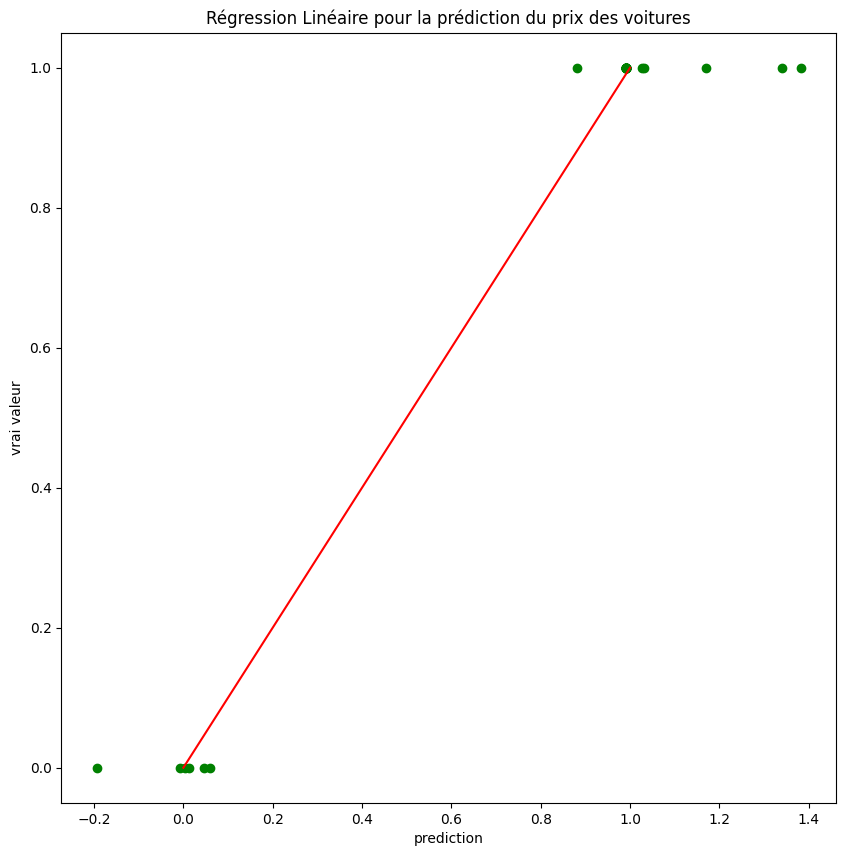

In [178]:
fig = plt.figure(figsize = (10,10))
pred_test = regressor.predict(X_test_only_numeric)
plt.scatter(pred_test, y_test, c='green')

plt.plot((y_test.min(), y_test.max()), (y_test.min(), y_test.max()), color = 'red')
plt.xlabel("prediction")
plt.ylabel("vrai valeur")
plt.title('Régression Linéaire pour la prédiction du prix des voitures')

plt.show()

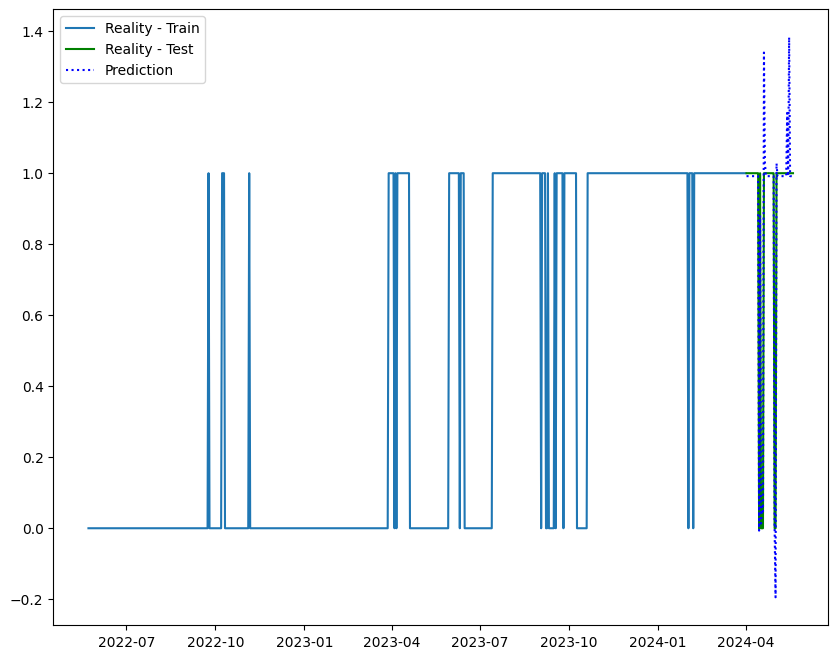

In [179]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['datetime'], y_train, label = 'Reality - Train')
plt.plot(X_test['datetime'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['datetime'], pred_test, ':b', label = 'Prediction')
plt.legend()

In [180]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, pred_test))



(0.0072108274, 0.08491659, 0.034754623, 0.9328945783365342)


#### XGBOOST

In [181]:
import xgboost as xgb
model = xgb.XGBRegressor()

In [182]:
model.fit(X_train_only_numeric, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [183]:
X_test_only_numeric = X_test[past_close_columns]
predictions = model.predict(X_test_only_numeric)
predictions

array([9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 1.6883381e-04, 9.9534625e-01, 1.7093535e-03,
       1.5093855e-03, 2.1666300e-03, 9.9791443e-01, 9.9571264e-01,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.0253445e-05, 3.4815741e-03, 1.0002714e+00,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01, 9.9222463e-01, 1.0031044e+00, 9.9222463e-01,
       9.9653387e-01, 9.9222463e-01, 9.9222463e-01, 9.9222463e-01,
       9.9222463e-01], dtype=float32)

In [184]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=0.0064


In [185]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, predictions))

(4.745e-05, 0.006888396, 0.006422107, 0.9995584207045176)


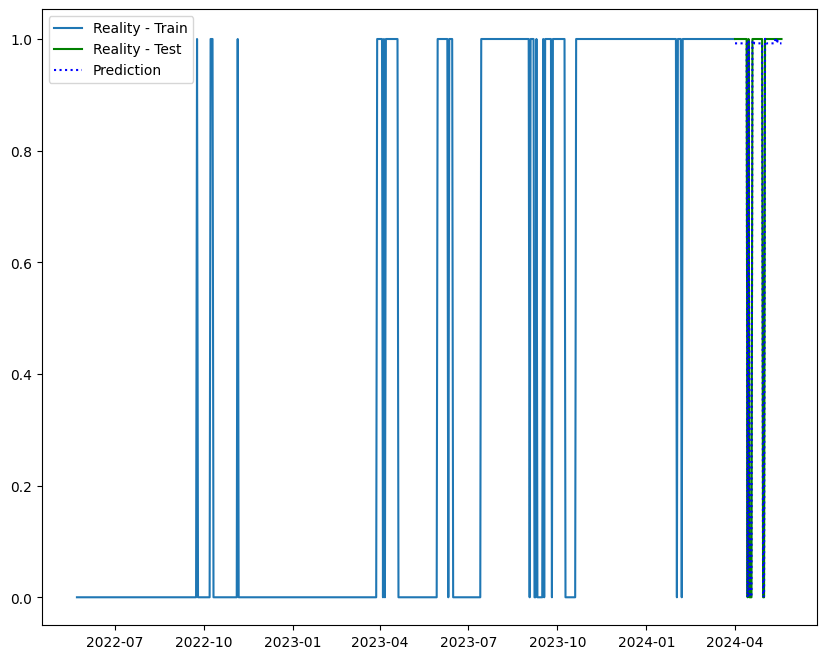

In [186]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['datetime'], y_train, label = 'Reality - Train')
plt.plot(X_test['datetime'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['datetime'], predictions, ':b', label = 'Prediction')
plt.legend()





#### LIGHTGBM

In [187]:
import lightgbm as lgb

In [188]:
model_lgb = lgb.LGBMRegressor()
model_lgb.fit(X_train_only_numeric, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 676, number of used features: 24
[LightGBM] [Info] Start training from score 0.411243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMRegressor()

In [189]:
X_test_only_numeric = X_test[past_close_columns]
predictions = model_lgb.predict(X_test_only_numeric)

from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test, predictions)
print(f'{test_mae=:.4f}')

test_mae=0.0119


In [190]:
def metrics_scikit_learn(y_test, predictions):
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, rmse, mae, r2

print(metrics_scikit_learn(y_test, predictions))

(0.0002328738731559671, 0.015260205541078636, 0.011877770615279394, 0.9978328287439213)


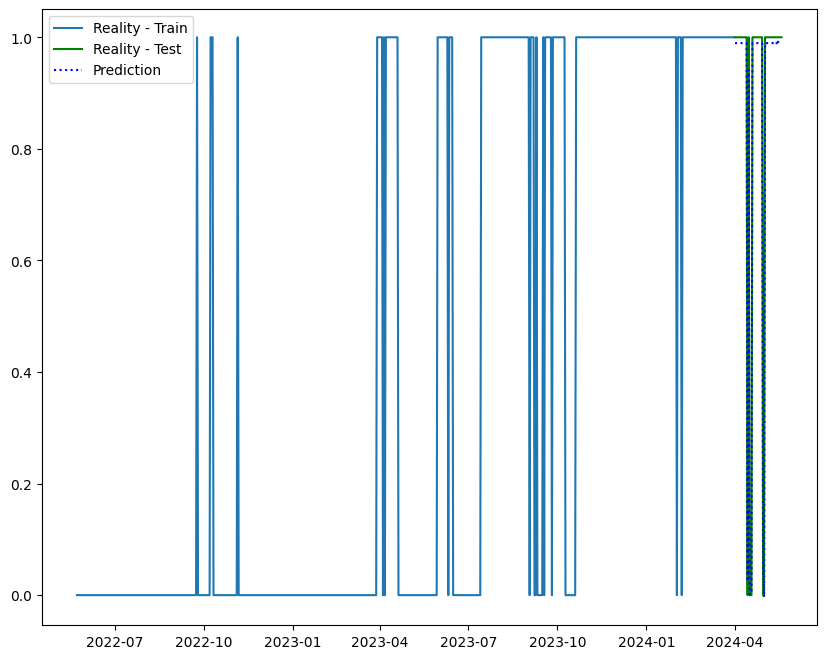

In [191]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
plt.plot(X_train['datetime'], y_train, label = 'Reality - Train')
plt.plot(X_test['datetime'], y_test, '-g', label = 'Reality - Test')
plt.plot(X_test['datetime'], predictions, ':b', label = 'Prediction')
plt.legend()
